## Problématique

## Analyse Exploratoire de Données 

#### Import des bibliothèques 

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

In [2]:
df = pd.read_csv('database.csv')
df.head()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


In [5]:
df.info()
print('=='*50)
print(df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        23412 non-null  str    
 1   Time                        23412 non-null  str    
 2   Latitude                    23412 non-null  float64
 3   Longitude                   23412 non-null  float64
 4   Type                        23412 non-null  str    
 5   Depth                       23412 non-null  float64
 6   Depth Error                 4461 non-null   float64
 7   Depth Seismic Stations      7097 non-null   float64
 8   Magnitude                   23412 non-null  float64
 9   Magnitude Type              23409 non-null  str    
 10  Magnitude Error             327 non-null    float64
 11  Magnitude Seismic Stations  2564 non-null   float64
 12  Azimuthal Gap               7299 non-null   float64
 13  Horizontal Distance         1604 non-null 

In [4]:
df.describe(include='all')

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
count,23412,23412,23412.000000,23412.000000,23412,23412.000000,4461.000000,7097.000000,23412.000000,23409,...,2564.000000,7299.000000,1604.000000,1156.000000,17352.000000,23412,23412,23412,23412,23412
unique,12401,20472,NaN,NaN,4,NaN,NaN,NaN,NaN,10,...,NaN,NaN,NaN,NaN,NaN,23412,13,48,24,2
top,03/11/2011,02:56:58,NaN,NaN,Earthquake,NaN,NaN,NaN,NaN,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,US,US,US,Reviewed
freq,128,5,NaN,NaN,23232,NaN,NaN,NaN,NaN,7722,...,NaN,NaN,NaN,NaN,NaN,1,20630,20350,10458,20773
mean,NaN,NaN,1.679033,39.639961,NaN,70.767911,4.993115,275.364098,5.882531,NaN,...,48.944618,44.163532,3.992660,7.662759,1.022784,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,30.113183,125.511959,NaN,122.651898,4.875184,162.141631,0.423066,NaN,...,62.943106,32.141486,5.377262,10.430396,0.188545,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,-77.080000,-179.997000,NaN,-1.100000,0.000000,0.000000,5.500000,NaN,...,0.000000,0.000000,0.004505,0.085000,0.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,-18.653000,-76.349750,NaN,14.522500,1.800000,146.000000,5.600000,NaN,...,10.000000,24.100000,0.968750,5.300000,0.900000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,-3.568500,103.982000,NaN,33.000000,3.500000,255.000000,5.700000,NaN,...,28.000000,36.000000,2.319500,6.700000,1.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,26.190750,145.026250,NaN,54.000000,6.300000,384.000000,6.000000,NaN,...,66.000000,54.000000,4.724500,8.100000,1.130000,NaN,NaN,NaN,NaN,NaN


#### Détection des valeurs manquantes

In [6]:
somme = df.isnull().sum()
frequence = somme / len(df) * 100

missing_data = pd.DataFrame({'somme': somme, 
'frequence': frequence})

print(missing_data)

                            somme  frequence
Date                            0   0.000000
Time                            0   0.000000
Latitude                        0   0.000000
Longitude                       0   0.000000
Type                            0   0.000000
Depth                           0   0.000000
Depth Error                 18951  80.945669
Depth Seismic Stations      16315  69.686486
Magnitude                       0   0.000000
Magnitude Type                  3   0.012814
Magnitude Error             23085  98.603280
Magnitude Seismic Stations  20848  89.048351
Azimuthal Gap               16113  68.823680
Horizontal Distance         21808  93.148813
Horizontal Error            22256  95.062361
Root Mean Square             6060  25.884162
ID                              0   0.000000
Source                          0   0.000000
Location Source                 0   0.000000
Magnitude Source                0   0.000000
Status                          0   0.000000


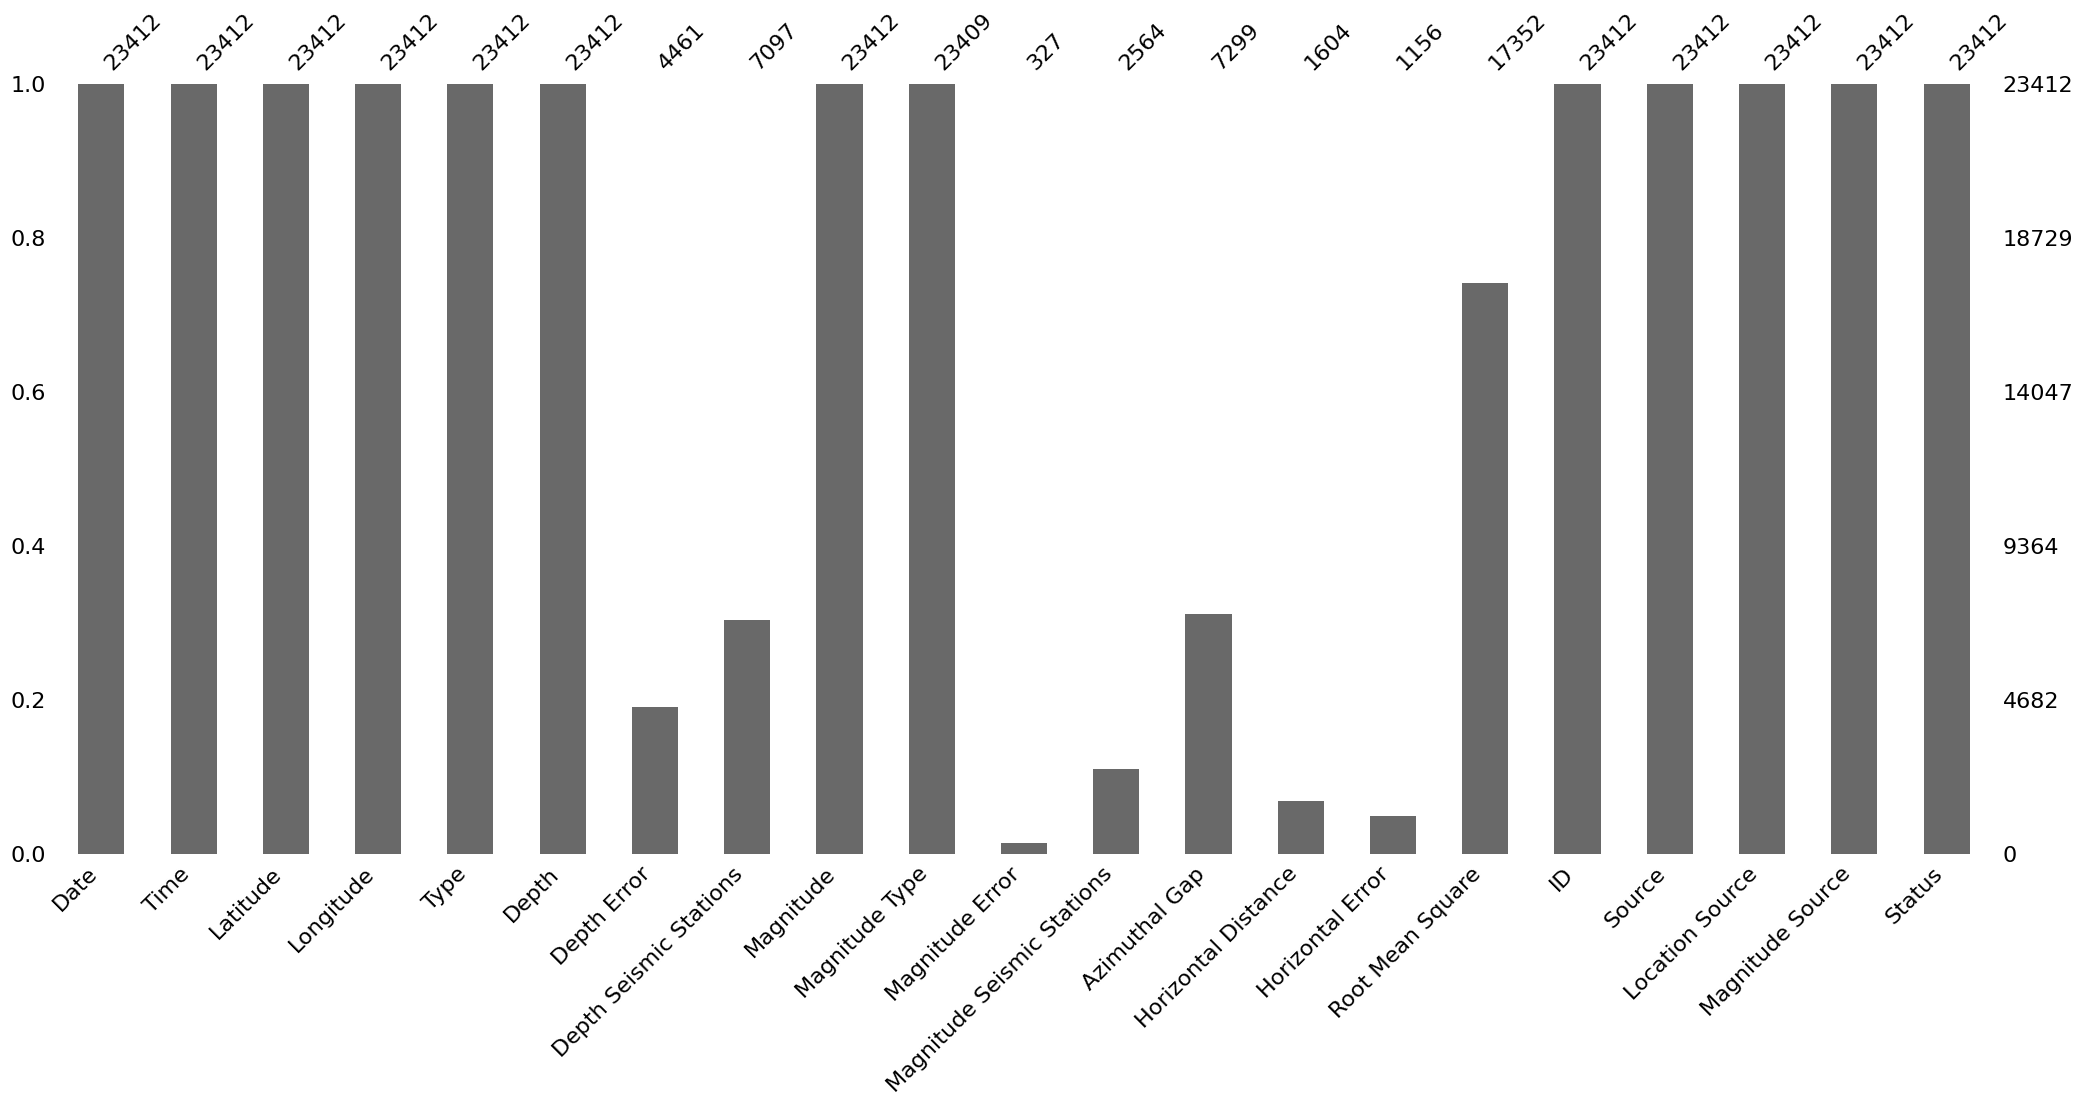

In [7]:
msno.bar(df)
plt.savefig('missing_data_bar.png')

#### Distribution des variables 

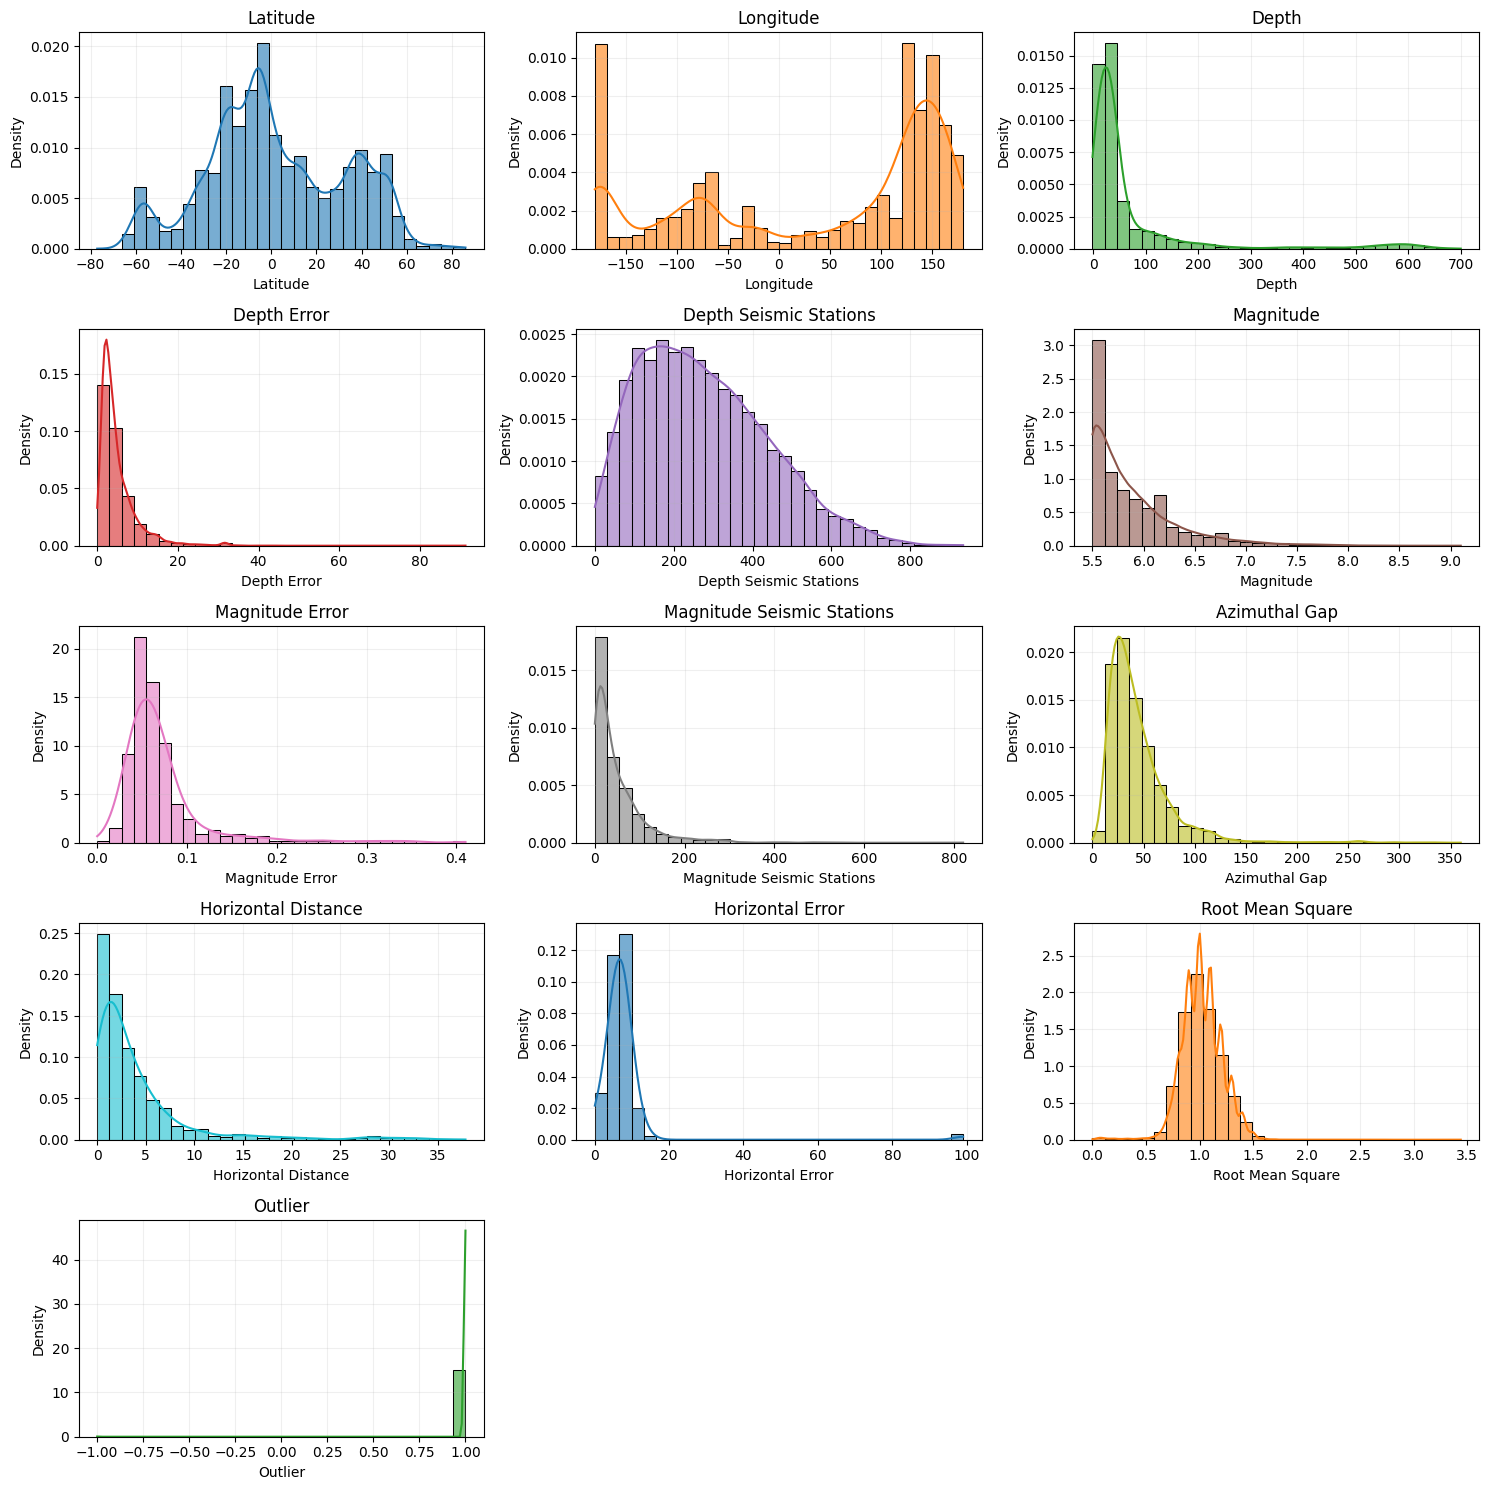

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sélection des colonnes numériques (utilise `df` existant)
numeric = df.select_dtypes(include=[np.number]).copy()
if numeric.shape[1] == 0:
    raise RuntimeError("Aucune colonne numérique trouvée dans `df`.")

cols = numeric.columns.tolist()
ncols = 3
nrows = (len(cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows))
axes = axes.flatten() if hasattr(axes, "__iter__") else [axes]

palette = sns.color_palette("tab10")

for i, col in enumerate(cols):
    color = palette[i % len(palette)]
    sns.histplot(numeric[col].dropna(), bins=30, ax=axes[i], color=color, kde=True, stat='density', alpha=0.6, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_ylabel('Density')
    axes[i].grid(alpha=0.2)

# Masquer les axes inutilisés
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('histograms_numeric.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
import geopandas as gpd
from shapely.geometry import Point

# Créer les points géographiques
geometry = [Point(lon, lat) for lon, lat in zip(df['Longitude'], df['Latitude'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')
print(gdf.shape)

# Charger les pays Natural Earth depuis l'URL officielle
world = gpd.read_file('https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip')
print("Colonnes disponibles dans world :")
print(world.columns.tolist())

# Jointure spatiale
gdf_joined = gpd.sjoin(
    gdf,
    world[['ADMIN', 'CONTINENT', 'geometry']],
    how='left',
    predicate='intersects'
)

print("\nColonnes après la jointure :")
print(gdf_joined.columns.tolist())

# Renommer les colonnes réellement présentes après la jointure
gdf_joined = gdf_joined.rename(columns={'ADMIN': 'Area', 'CONTINENT': 'Continent'})

# Vérification
print("\nTop 10 zones :")
print(gdf_joined['Area'].value_counts().head(10))
print(f"\nValeurs manquantes zone : {gdf_joined['Area'].isnull().sum()}")

# Remplissage des valeurs manquantes
gdf_joined['Area'] = gdf_joined['Area'].fillna('Ocean')
gdf_joined['Continent'] = gdf_joined['Continent'].fillna('Ocean')

# Copier la colonne `Area` dans le DataFrame d'origine `df` pour l'utiliser partout
# On réinitialise les indexes pour éviter les problèmes d'alignement éventuels
try:
    df = df.reset_index(drop=True)
    gdf_joined = gdf_joined.reset_index(drop=True)
    if 'Area' in gdf_joined.columns:
        df['Area'] = gdf_joined['Area'].fillna('Ocean')
        # Alias en anglais si nécessaire
        df['Country'] = df['Area']
    else:
        print("Colonne 'Area' introuvable dans gdf_joined — aucune modification effectuée sur df.")
except Exception as e:
    print('Erreur lors de la copie de la colonne Area vers df:', e)


(23412, 23)
Colonnes disponibles dans world :
['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3', 'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN', 'ADM0_A3', 'GEOU_DIF', 'GEOUNIT', 'GU_A3', 'SU_DIF', 'SUBUNIT', 'SU_A3', 'BRK_DIFF', 'NAME', 'NAME_LONG', 'BRK_A3', 'BRK_NAME', 'BRK_GROUP', 'ABBREV', 'POSTAL', 'FORMAL_EN', 'FORMAL_FR', 'NAME_CIAWF', 'NOTE_ADM0', 'NOTE_BRK', 'NAME_SORT', 'NAME_ALT', 'MAPCOLOR7', 'MAPCOLOR8', 'MAPCOLOR9', 'MAPCOLOR13', 'POP_EST', 'POP_RANK', 'POP_YEAR', 'GDP_MD', 'GDP_YEAR', 'ECONOMY', 'INCOME_GRP', 'FIPS_10', 'ISO_A2', 'ISO_A2_EH', 'ISO_A3', 'ISO_A3_EH', 'ISO_N3', 'ISO_N3_EH', 'UN_A3', 'WB_A2', 'WB_A3', 'WOE_ID', 'WOE_ID_EH', 'WOE_NOTE', 'ADM0_ISO', 'ADM0_DIFF', 'ADM0_TLC', 'ADM0_A3_US', 'ADM0_A3_FR', 'ADM0_A3_RU', 'ADM0_A3_ES', 'ADM0_A3_CN', 'ADM0_A3_TW', 'ADM0_A3_IN', 'ADM0_A3_NP', 'ADM0_A3_PK', 'ADM0_A3_DE', 'ADM0_A3_GB', 'ADM0_A3_BR', 'ADM0_A3_IL', 'ADM0_A3_PS', 'ADM0_A3_SA', 'ADM0_A3_EG', 'ADM0_A3_MA', 'ADM0_A3_PT', 'ADM0_A3_AR', 'ADM0_A3_JP',

Séismes océaniques : 18523
    Latitude  Longitude  Magnitude  Depth
0     19.246    145.616        6.0  131.6
1      1.863    127.352        5.8   80.0
2    -20.579   -173.972        6.2   20.0
3    -59.076    -23.557        5.8   15.0
4     11.938    126.427        5.8   15.0
5    -13.405    166.629        6.7   35.0
7    -13.309    166.212        6.0   35.0
8    -56.452    -27.043        6.0   95.0
9    -24.563    178.487        5.8  565.0
11    -2.608    125.952        8.2   20.0
Séismes terrestres : 4889
Séismes océaniques : 18523

Magnitude moyenne (terre) : 5.92
Magnitude moyenne (océan) : 5.87

Profondeur moyenne (terre) : 65.92 km
Profondeur moyenne (océan) : 72.05 km


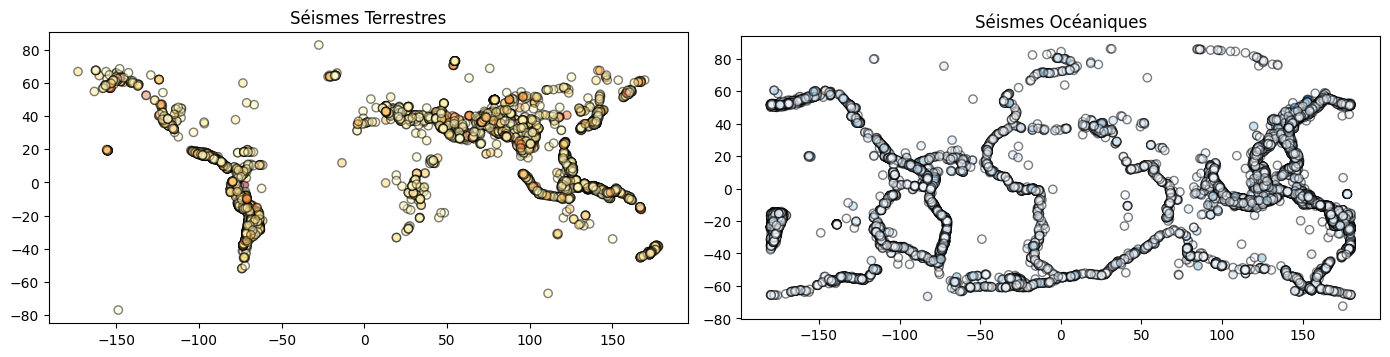

Area
Ocean                       18523
Indonesia                     487
Papua New Guinea              457
Chile                         400
China                         358
United States of America      245
Peru                          239
Argentina                     232
Japan                         196
Mexico                        191
Philippines                   173
Afghanistan                   162
Iran                          162
Russia                        158
Kazakhstan                    107
Name: count, dtype: int64

Top 10 séismes océaniques les plus puissants :
       Latitude  Longitude  Magnitude  Depth
17083     3.295     95.982        9.1   30.0
20501    38.297    142.373        9.1   29.0
19928   -36.122    -72.898        8.8   22.9
16       51.251    178.715        8.7   30.3
17329     2.085     97.108        8.6   30.0
21219     2.327     93.063        8.6   20.0
15440   -16.265    -73.641        8.4   33.0
18615    -4.438    101.367        8.4   34.0
12119 

In [12]:
ocean_earthquakes = gdf_joined[gdf_joined['Area'] == 'Ocean']
print(f"Séismes océaniques : {len(ocean_earthquakes)}")
print(ocean_earthquakes[['Latitude', 'Longitude', 'Magnitude', 'Depth']].head(10))
terrestrial = gdf_joined[gdf_joined['Area'] != 'Ocean']
ocean = gdf_joined[gdf_joined['Area'] == 'Ocean']

print(f"Séismes terrestres : {len(terrestrial)}")
print(f"Séismes océaniques : {len(ocean)}")
print(f"\nMagnitude moyenne (terre) : {terrestrial['Magnitude'].mean():.2f}")
print(f"Magnitude moyenne (océan) : {ocean['Magnitude'].mean():.2f}")
print(f"\nProfondeur moyenne (terre) : {terrestrial['Depth'].mean():.2f} km")
print(f"Profondeur moyenne (océan) : {ocean['Depth'].mean():.2f} km")
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Séismes terrestres
terrestrial.plot(ax=ax1, alpha=0.5, edgecolor='k', column='Magnitude', cmap='YlOrRd')
ax1.set_title('Séismes Terrestres')

# Séismes océaniques
ocean.plot(ax=ax2, alpha=0.5, edgecolor='k', column='Magnitude', cmap='Blues')
ax2.set_title('Séismes Océaniques')

plt.tight_layout()
plt.savefig('images/terrestrial_vs_ocean_earthquakes.png')
plt.show()
# Top 15 zones avec le plus de séismes
print(gdf_joined['Area'].value_counts().head(15))

# Zones les plus sismiques en océan
top_ocean_coords = ocean.nlargest(10, 'Magnitude')[['Latitude', 'Longitude', 'Magnitude', 'Depth']]
print("\nTop 10 séismes océaniques les plus puissants :")
print(top_ocean_coords)

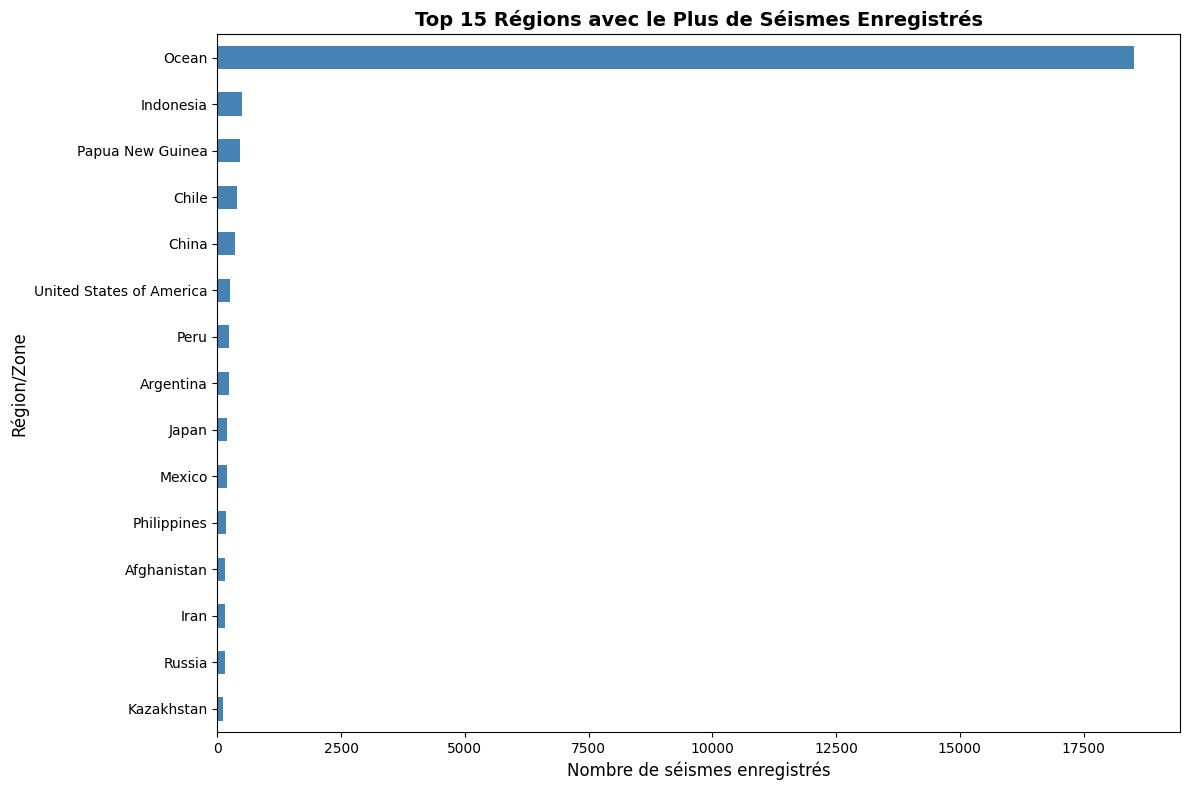


RÉSUMÉ : Top 15 Régions avec le Plus de Séismes
 1. Ocean                          : 18523 séismes
 2. Indonesia                      :   487 séismes
 3. Papua New Guinea               :   457 séismes
 4. Chile                          :   400 séismes
 5. China                          :   358 séismes
 6. United States of America       :   245 séismes
 7. Peru                           :   239 séismes
 8. Argentina                      :   232 séismes
 9. Japan                          :   196 séismes
10. Mexico                         :   191 séismes
11. Philippines                    :   173 séismes
12. Afghanistan                    :   162 séismes
13. Iran                           :   162 séismes
14. Russia                         :   158 séismes
15. Kazakhstan                     :   107 séismes


In [20]:
# Graphique des régions/zones avec le plus de séismes enregistrés
top_areas = gdf_joined['Area'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 8))
top_areas.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Nombre de séismes enregistrés', fontsize=12)
ax.set_ylabel('Région/Zone', fontsize=12)
ax.set_title('Top 15 Régions avec le Plus de Séismes Enregistrés', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('images/top_areas_earthquakes.png', dpi=300, bbox_inches='tight')
plt.show()

# Affichage du tableau récapitulatif
print("\n" + "="*60)
print("RÉSUMÉ : Top 15 Régions avec le Plus de Séismes")
print("="*60)
for idx, (area, count) in enumerate(top_areas.items(), 1):
    print(f"{idx:2d}. {area:30s} : {count:5d} séismes")
print("="*60)

#### Evolution temporelle des séismes au cours des années 

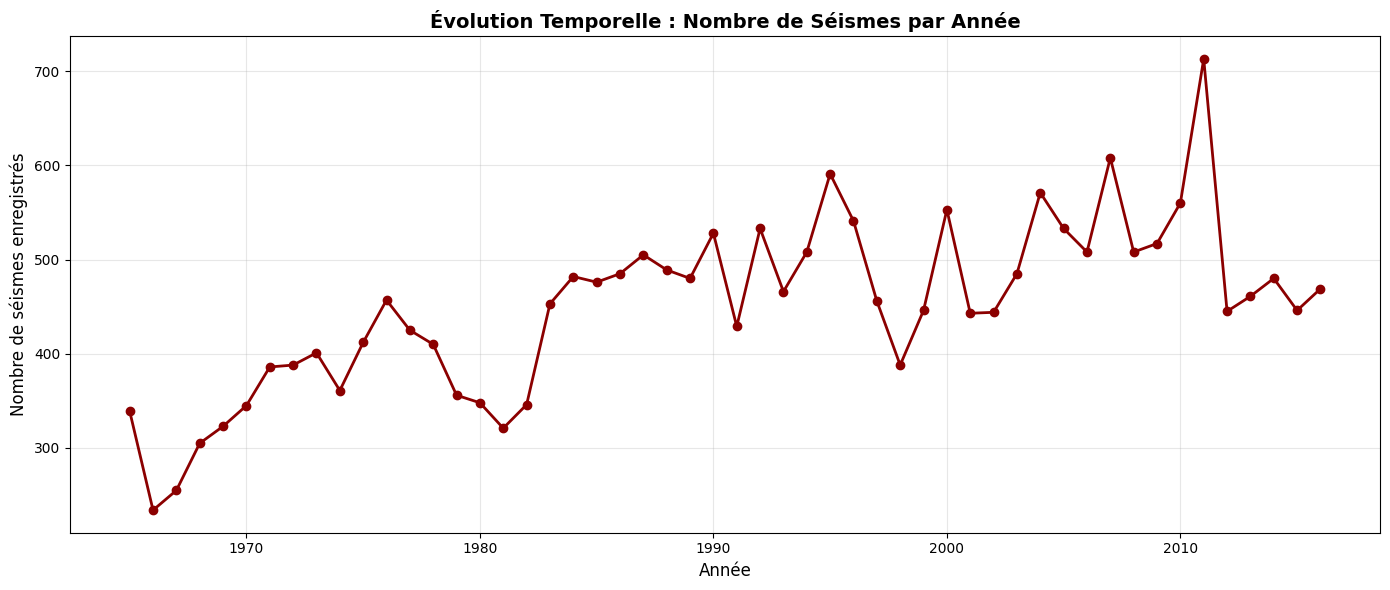

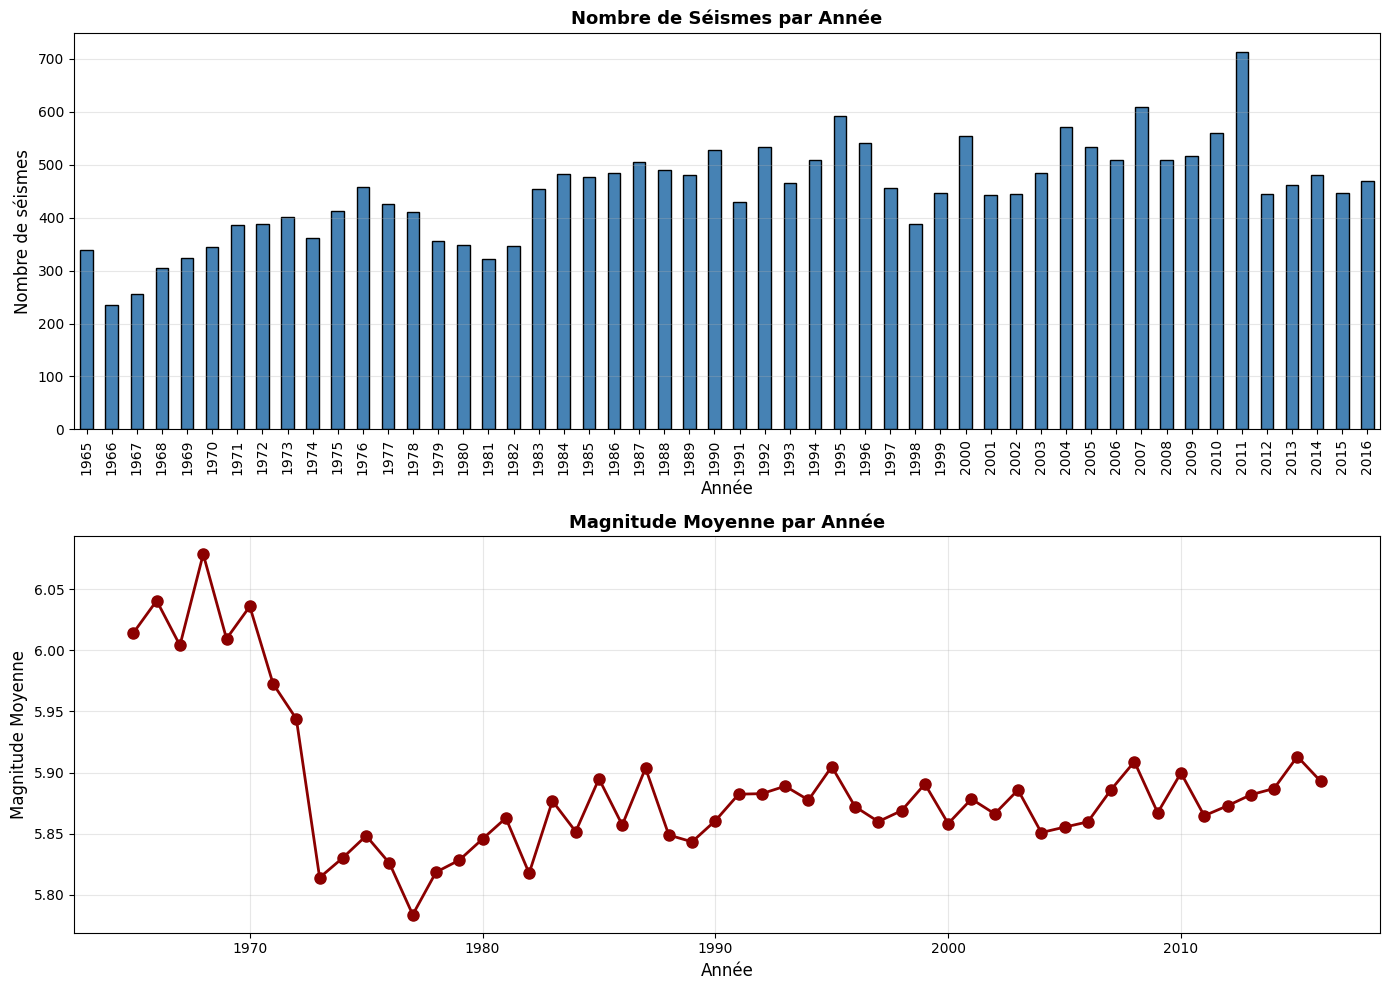


RÉSUMÉ : Évolution Temporelle des Séismes
Période : 1965 - 2016
Total séismes : 23412

Magnitude moyenne globale : 5.88
Profondeur moyenne globale : 70.77 km
Profondeur minimale : -1.10 km
Profondeur maximale : 700.00 km


In [19]:
# Créer une colonne Date - gérer plusieurs formats (ISO8601 inclus)
if 'Date' in gdf_joined.columns:
    gdf_joined['Date'] = pd.to_datetime(gdf_joined['Date'], utc=True, errors='coerce')
elif 'DateTime' in gdf_joined.columns:
    gdf_joined['Date'] = pd.to_datetime(gdf_joined['DateTime'], utc=True, errors='coerce')
elif 'Timestamp' in gdf_joined.columns:
    gdf_joined['Date'] = pd.to_datetime(gdf_joined['Timestamp'], utc=True, errors='coerce')
else:
    raise KeyError('Aucune colonne de date reconnue (attendue: Date, DateTime ou Timestamp)')

# Extraire l'année
gdf_joined['Year'] = gdf_joined['Date'].dt.year

# Évolution temporelle : Nombre de séismes par année (graphique 1)
earthquakes_per_year = gdf_joined.groupby('Year').size()

fig, ax = plt.subplots(figsize=(14, 6))
earthquakes_per_year.plot(kind='line', ax=ax, marker='o', linewidth=2, markersize=6, color='darkred')
ax.set_xlabel('Année', fontsize=12)
ax.set_ylabel('Nombre de séismes enregistrés', fontsize=12)
ax.set_title('Évolution Temporelle : Nombre de Séismes par Année', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/earthquakes_per_year.png', dpi=300, bbox_inches='tight')
plt.show()

# Calcul de la magnitude moyenne par année (utilisée dans le graphique combiné)
magnitude_per_year = gdf_joined.groupby('Year')['Magnitude'].mean()

# Graphique combiné : Nombre et Magnitude (graphique 3)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Nombre de séismes
earthquakes_per_year.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_xlabel('Année', fontsize=12)
ax1.set_ylabel('Nombre de séismes', fontsize=12)
ax1.set_title('Nombre de Séismes par Année', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Magnitude moyenne
magnitude_per_year.plot(kind='line', ax=ax2, marker='o', linewidth=2, markersize=8, color='darkred')
ax2.set_xlabel('Année', fontsize=12)
ax2.set_ylabel('Magnitude Moyenne', fontsize=12)
ax2.set_title('Magnitude Moyenne par Année', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/evolution_temporelle_combined.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("RÉSUMÉ : Évolution Temporelle des Séismes")
print("="*60)
print(f"Période : {int(gdf_joined['Year'].min())} - {int(gdf_joined['Year'].max())}")
print(f"Total séismes : {len(gdf_joined)}")
print(f"\nMagnitude moyenne globale : {gdf_joined['Magnitude'].mean():.2f}")
print(f"Profondeur moyenne globale : {gdf_joined['Depth'].mean():.2f} km")
print(f"Profondeur minimale : {gdf_joined['Depth'].min():.2f} km")
print(f"Profondeur maximale : {gdf_joined['Depth'].max():.2f} km")
print("="*60)

#### Corrélation entre variables 

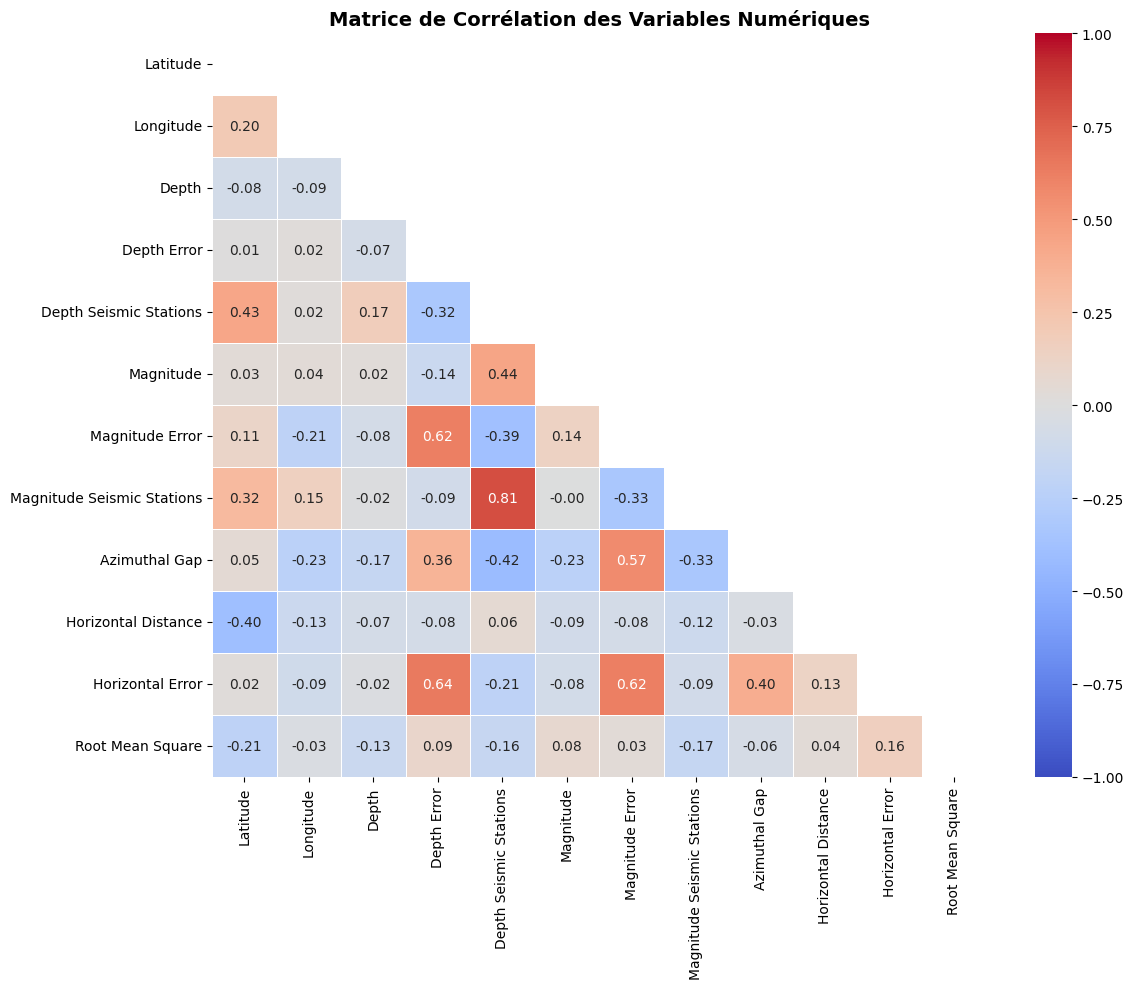

In [25]:
import numpy as np

# Utiliser uniquement les colonnes numériques pour la matrice de corrélation
numeric_df = df.select_dtypes(include=[np.number]).copy()
if numeric_df.shape[1] == 0:
    raise RuntimeError('Aucune colonne numérique disponible pour calculer la corrélation.')

correlation = numeric_df.corr(method='pearson')

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, mask=mask, vmin=-1, vmax=1)
plt.title('Matrice de Corrélation des Variables Numériques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/correlation_numeric.png', dpi=300, bbox_inches='tight')
plt.show()

#### Détection des outliers

In [26]:
# sur le plan univarié 
# méthode IQR 
def detec_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    borne_infer = Q1 - (1.5 * IQR)
    borne_super = Q3 + (1.5 * IQR)

    return data[(data[column] < borne_infer) | (data[column] > borne_super)]

outliers = detec_outliers(df, 'Magnitude')
print('Outliers détectés')
print(outliers)

Outliers détectés
             Date      Time  Latitude  Longitude        Type   Depth  \
5      01/10/1965  13:36:32  -13.4050   166.6290  Earthquake   35.00   
11     01/24/1965  00:11:17   -2.6080   125.9520  Earthquake   20.00   
16     02/04/1965  05:01:22   51.2510   178.7150  Earthquake   30.30   
26     02/04/1965  08:40:44   51.4430   179.6050  Earthquake   30.00   
62     02/23/1965  22:11:47  -25.6330   -70.6790  Earthquake   35.00   
...           ...       ...       ...        ...         ...     ...   
23369  12/08/2016  17:38:46  -10.6787   161.3214  Earthquake   40.00   
23373  12/09/2016  19:10:07  -10.7490   161.1316  Earthquake   19.73   
23386  12/17/2016  10:51:10   -4.5049   153.5216  Earthquake   94.54   
23399  12/21/2016  00:17:15   -7.5082   127.9206  Earthquake  152.00   
23403  12/25/2016  14:22:27  -43.4029   -73.9395  Earthquake   38.00   

       Depth Error  Depth Seismic Stations  Magnitude Magnitude Type  ...  \
5              NaN                     N

In [27]:
# Isolation Forest (sur variables numériques uniquement)
from sklearn.ensemble import IsolationForest

# 1) Garder seulement les colonnes numériques
X_iso = df.select_dtypes(include=[np.number]).copy()

# 2) Retirer une éventuelle colonne cible déjà créée
if 'Outlier' in X_iso.columns:
    X_iso = X_iso.drop(columns=['Outlier'])



iso_forest = IsolationForest(contamination=0.001, random_state=42)
outlier_labels = iso_forest.fit_predict(X_iso)

df['Outlier'] = outlier_labels
outliers = df[df['Outlier'] == -1]

print('Outliers détectés (Isolation Forest)')
n_outliers_iso = (outlier_labels == -1).sum()
print(f"Outliers détectés : {n_outliers_iso} ({n_outliers_iso/len(df)*100:.2f}%)")
print(f"Colonnes utilisées : {X_iso.shape[1]}")

Outliers détectés (Isolation Forest)
Outliers détectés : 24 (0.10%)
Colonnes utilisées : 12


#### Détection des doublons

In [28]:
doublons = df.duplicated().sum()
print(f"Nombre de doublons : {doublons}")

Nombre de doublons : 0


In [32]:
df.columns

Index(['Date', 'Time', 'Latitude', 'Longitude', 'Type', 'Depth', 'Depth Error',
       'Depth Seismic Stations', 'Magnitude', 'Magnitude Type',
       'Magnitude Error', 'Magnitude Seismic Stations', 'Azimuthal Gap',
       'Horizontal Distance', 'Horizontal Error', 'Root Mean Square', 'ID',
       'Source', 'Location Source', 'Magnitude Source', 'Status', 'Outlier',
       'Area', 'Country'],
      dtype='str')